In [ ]:
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch
from tqdm import trange
import random
import math


class ConnectFour:
    def __init__(self):
        self.row=10
        self.col=10
        self.action_size=self.col
        self.in_a_row = 4
    
    def __repr__(self):
        return "connect4"

    def init_game(self):
        return np.zeros((self.row,self.col))

    def get_next_state(self,state,action,player):
        row = np.max(np.where(state[:,action]==0))
        state[row,action]=player
        return state

    def get_valid_moves(self,state):
        return (state[0]==0).astype(np.uint8)

    def check_win(self,state,action):
        if(action==None):
            return False
        
        row = np.min(np.where(state[:,action]!=0))
        col = action
        player = state[row][col]


        def count(offset_row, offset_column):
            for i in range(1, self.in_a_row):
                r = row + offset_row * i
                c = action + offset_column * i
                if (
                    r < 0 
                    or r >= self.row_count
                    or c < 0 
                    or c >= self.column_count
                    #see if its inside the bounds and then add to count
                    or state[r][c] != player
                ):
                    return i - 1
            return self.in_a_row - 1

        return (
            count(1, 0) >= self.in_a_row - 1 # vertical
            or (count(0, 1) + count(0, -1)) >= self.in_a_row - 1 # horizontal
            or (count(1, 1) + count(-1, -1)) >= self.in_a_row - 1 # top left diagonal
            or (count(1, -1) + count(-1, 1)) >= self.in_a_row - 1 # top right diagonal
        )
    

    def get_value_and_is_terminated(self,state,action):
        #action was taken by parent, so the player in check win will be parent.
        if self.check_win(state,action):
            return 1, True
        if np.sum(self.get_valid_moves(state))==0:
            return 0, True
        return 0,False

    def get_opponent(self,player):
        return -player

    def get_opponent_value(self,value):
        return -value

    def change_perspective(self,state,player):
        return state*player

    def get_encoded_state(self,state):
      #stack all states of -1,0,1 in seperate channels
      encoded_state = np.stack(
          (state==-1,state==0,state==1)
      ).astype(np.float32)
      return encoded_state

#MCTS
class Node:
    def __init__(self,game,args,state,parent=None,action_taken=None,prior=0,visit_count=0):
        self.game = game
        self.args = args
        self.state = state
        self.parent:Node = parent
        self.action_taken = action_taken

        self.children = []

        self.visit_count = visit_count
        self.value_sum = 0
        self.prior = prior
        # CHANGED: exploration constant is configurable through args.
        self.C = self.args.get("C", np.sqrt(2))

    def is_fully_expanded(self):
        #game terminated and no children for the node
        return len(self.children)!= 0

    def select(self):
        best_child = None
        best_ucb = -np.inf

        for child in self.children:
            ucb = self.get_ucb(child)
            if ucb>best_ucb:
                best_child = child
                best_ucb = ucb
        return best_child

    def get_ucb(self, child):
        if child.visit_count == 0:
            q_value = 0
        else:
            q_value = 1 - ((child.value_sum / child.visit_count) + 1) / 2
        return q_value + self.args['C'] * (math.sqrt(self.visit_count) / (child.visit_count + 1)) * child.prior

    def expand(self,policy):
      for action,prob in enumerate(policy):
        if prob>0:
          child_state = self.state.copy()
          child_state = self.game.get_next_state(child_state,action,1)
          child_state = self.game.change_perspective(child_state,-1)
          child = Node(self.game,self.args,child_state,self,action,prob)
          self.children.append(child)

    def backpropagate(self,value):
        self.value_sum+=value
        self.visit_count+=1
        value = self.game.get_opponent_value(value)
        if self.parent is not None:
            self.parent.backpropagate(value)

class MonteCarloTreeSearch:
    def __init__(self,game,args,model):
        self.game = game
        self.args = args
        self.model = model

    def search(self,state):
        #define root node with beginning state
        root = Node(self.game,self.args, state,visit_count=1) 
        state_tensor = torch.tensor(self.game.get_encoded_state(state),device=self.model.device).unsqueeze(0)

        policy,value= self.model(state_tensor)

        policy = torch.softmax(policy,axis=0).squeeze(0)
        policy = torch.tensor(policy,device="cpu").numpy()
        

        policy = (1 - self.args['dirichlet_epsilon'])*policy + \
            self.args['dirichlet_epsilon']*np.random.dirichlet([self.args['dirichlet_alpha']]*self.game.action_size)

        valid_moves = self.game.get_valid_moves(state)
        #print(valid_moves.shape)
        policy = policy*valid_moves
        policy = policy/np.sum(policy)
        root.expand(policy)



        for i in range(self.args["num_searches"]):
            node = root
            #select
            while node.is_fully_expanded():
                #select best node based on ucb
                node = node.select()

            #see if the node is a terminal state of the game, action taken was from the parent (aka the opponent)
            value, is_terminal = self.game.get_value_and_is_terminated(node.state,node.action_taken)
            #the previous line gives the value of the opponent from the childs perspecitve its the opposite
            value = self.game.get_opponent_value(value)

            if not is_terminal:
                #simulation is not there, the model gives P,v and all nodes are expanded simulataneously
                state = self.game.get_encoded_state(node.state)
                state = torch.tensor(state,device=self.model.device).unsqueeze(0)
                with torch.no_grad():

                    policy, value = self.model(state) #policy logits
                    policy = torch.softmax(policy,axis=0).squeeze(0)
                    policy = torch.tensor(policy,device="cpu").numpy()

                #apply the policy only to the valid moves
                valid_moves = self.game.get_valid_moves(node.state)
                policy*=valid_moves
                policy_sum = np.sum(policy)
                if policy_sum <= 0 or not np.isfinite(policy_sum):
                    policy = valid_moves.astype(np.float32)
                    policy /= np.sum(policy)
                else:
                    policy /= policy_sum

                value = value.item()
                #expansion
                node.expand(policy)
            #backprop
            node.backpropagate(value)

        action_probs = np.zeros(self.game.action_size)
        #from the root we need to make only one move, to select the child (select the action most visited)
        for child in root.children:
            action_probs[child.action_taken]=child.visit_count
        total_visits = np.sum(action_probs)
        if total_visits > 0:
            action_probs /= total_visits
        return action_probs
        #return visit_counts



In [70]:
class ResNet(nn.Module):
    def __init__(self,game,num_res,num_hidden,device):
        super().__init__()
        self.device = device
        self.startblock=nn.Sequential(
            nn.Conv2d(3,num_hidden,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_hidden),
            nn.ReLU()
        )
        self.backbone = nn.ModuleList(
            [ResBlock(num_hidden) for i in range(num_res)]
        )

        self.policy_head = nn.Sequential(
            nn.Conv2d(num_hidden,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*game.row*game.col,game.action_size)
        )

        self.value_head = nn.Sequential(
            nn.Conv2d(num_hidden,3,kernel_size=3,padding=1),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3*game.row*game.col,1),
            nn.Tanh()
        )

        self.to(device)
        
    def forward(self,x):
        x = self.startblock(x)
        for block in self.backbone:
            x = block(x)
        policy = self.policy_head(x)
        value = self.value_head(x)
        return policy,value

class ResBlock(nn.Module):
    def __init__(self,num_hidden):
        super().__init__()
        self.conv1= nn.Conv2d(num_hidden,num_hidden,kernel_size=3,padding=1)
        self.bn1 = nn.BatchNorm2d(num_hidden)
        self.conv2 = nn.Conv2d(num_hidden,num_hidden,kernel_size=3,padding=1)
        self.bn2 = nn.BatchNorm2d(num_hidden)

    def forward(self,x):
        residual = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.bn2(self.conv2(x))
        x = x + residual
        x = F.relu(x)
        return x



In [ ]:
class AlphaZero:
    def __init__(self, model, optimizer, game, args):
        self.model = model
        self.optimizer = optimizer
        self.game = game
        self.args = args
        self.mcts = MonteCarloTreeSearch(game, args, model)
        
    def selfPlay(self):
        memory = []
        player = 1
        state = self.game.init_game()
        
        while True:
            neutral_state = self.game.change_perspective(state, player)
            action_probs = self.mcts.search(neutral_state)    
            memory.append((neutral_state, action_probs, player))
        
            ## use temperature here to visit states which havent been visited more
            ## increase entropy of action_probs
            
            temperature_action_probs = action_probs **(1/self.args['temperature'])
            temperature_action_probs/=np.sum(temperature_action_probs)
            action = np.random.choice(self.game.action_size, p=temperature_action_probs)
            
            state = self.game.get_next_state(state, action, player)
            
            value, is_terminal = self.game.get_value_and_is_terminated(state, action)
            
            if is_terminal:
                returnMemory = []
                for hist_neutral_state, hist_action_probs, hist_player in memory:
                    hist_outcome = value if hist_player == player else self.game.get_opponent_value(value)
                    returnMemory.append((
                        self.game.get_encoded_state(hist_neutral_state),
                        hist_action_probs,
                        hist_outcome
                    ))
                return returnMemory
            
            player = self.game.get_opponent(player)
                
    def train(self, memory):
        random.shuffle(memory)
        for batchIdx in range(0, len(memory), self.args['batch_size']):
            sample = memory[batchIdx:batchIdx+self.args['batch_size']] 
            state, policy_targets, value_targets = zip(*sample)
            
            state, policy_targets, value_targets = np.array(state), np.array(policy_targets), np.array(value_targets).reshape(-1, 1)
            
            state = torch.tensor(state, dtype=torch.float32,device=self.model.device)
            policy_targets = torch.tensor(policy_targets, dtype=torch.float32,device=self.model.device)
            value_targets = torch.tensor(value_targets, dtype=torch.float32,device=self.model.device)
            
            out_policy, out_value = self.model(state)
            
            policy_loss = F.cross_entropy(out_policy, policy_targets)
            value_loss = F.mse_loss(out_value, value_targets)
            loss = policy_loss + value_loss
            
            self.optimizer.zero_grad() 
            loss.backward()
            self.optimizer.step() 
    
    def learn(self):
        for iteration in range(self.args['num_iterations']):
            memory = []
            
            self.model.eval()
            for selfPlay_iteration in trange(self.args['num_selfPlay_iterations']):
                memory += self.selfPlay()
                
            self.model.train()
            for epoch in trange(self.args['num_epochs']):
                self.train(memory)
            
            torch.save(self.model.state_dict(), f"model_mar9{iteration}_{self.game}.pt")
            torch.save(self.optimizer.state_dict(), f"optimizer_mar9{iteration}_{self.game}.pt")

In [ ]:
tictactoe = ConnectFour()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet(tictactoe, 4, 64, device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

args = {
    'C': 2,
    'num_searches': 60,
    'num_iterations': 3,
    'num_selfPlay_iterations': 500,
    'num_epochs': 4,
    'batch_size': 64,
    'temperature': 1.25,
    'dirichlet_epsilon':0.25,
    'dirichlet_alpha':0.3
}
alphaZero = AlphaZero(model, optimizer, tictactoe, args)
alphaZero.learn()

  0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipykernel_562773/907409803.py:135: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  policy = torch.tensor(policy,device="cpu").numpy()
/tmp/ipykernel_562773/907409803.py:169: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  policy = torch.tensor(policy,device="cpu").numpy()
100%|██████████| 4/4 [00:00<00:00,  8.60it/s]


-0.6959055066108704
[[-1.  0. -1.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]]


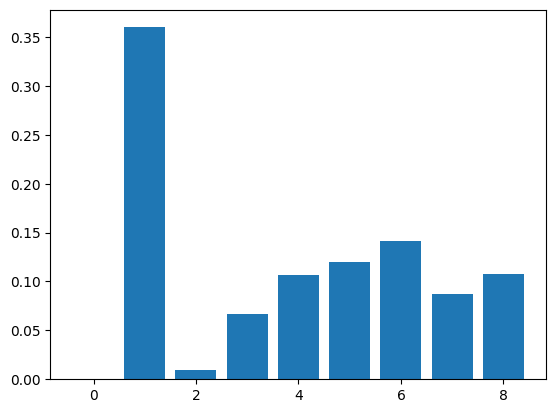

In [ ]:

import matplotlib.pyplot as plt

tictactoe = ConnectFour()

state = tictactoe.init_game()
state = tictactoe.get_next_state(state, 2, -1)
state = tictactoe.get_next_state(state, 0, -1)



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoded_state = tictactoe.get_encoded_state(state)

tensor_state = torch.tensor(encoded_state,device=device).unsqueeze(0)

model = ResNet(tictactoe, 4, 64,device=device)
model.load_state_dict(torch.load('model_mar92.pt'))
model.eval()

policy, value = model(tensor_state)
value = value.item()
policy = torch.softmax(policy, axis=1).squeeze(0).detach().cpu().numpy()

print(value)

print(state)
#print(tensor_state)

plt.bar(range(tictactoe.action_size), policy)
plt.show()


In [ ]:
#GAMEPLAY
if __name__ == "__main__":
    tct = ConnectFour()
    player = 1
    args = {'num_iter': 5000, 'C': 2}
    model = ResNet(tct,4,64)
    model.eval()
    mcts = MonteCarloTreeSearch(tct,args,model)
    state = tct.init_game()

    while True:
        print(state)
        if player==1:
            valid_moves = tct.get_valid_moves(state)
            print("valid moves: ", [i for i in range(tct.action_size) if valid_moves[i]==1])
            action = int(input(f"{player}:"))
            if valid_moves[action]==0:
                print("action not valid")
                continue
        else:
            #according to any player, they are 1, and their opponent is -1
            neutral_state = tct.change_perspective(state,player)
            mcts_probs = mcts.search(neutral_state)
            #plt.bar(range(tct.action_size),mcts_probs,width=1,bottom=False)
            action = np.argmax(mcts_probs)

        state = tct.get_next_state(state,action,player)
        value, is_terminal = tct.get_value_and_is_terminated(state,action)
        if is_terminal:
            print(state)
            if value ==1:
                print(player," won")
            else:
                print("draw")
            break
        player = tct.get_opponent(player)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
valid moves:  [0, 1, 2, 3, 4, 5, 6, 7, 8]
1:3
[[0. 0. 0.]
 [1. 0. 0.]
 [0. 0. 0.]]
[[ 0.  0.  0.]
 [ 1.  0.  0.]
 [ 0.  0. -1.]]
valid moves:  [0, 1, 2, 4, 5, 6, 7]
1:4
[[ 0.  0.  0.]
 [ 1.  1.  0.]
 [ 0.  0. -1.]]
[[ 0.  0.  0.]
 [ 1.  1. -1.]
 [ 0.  0. -1.]]
valid moves:  [0, 1, 2, 6, 7]
1:2
[[ 0.  0.  1.]
 [ 1.  1. -1.]
 [ 0.  0. -1.]]
[[ 0.  0.  1.]
 [ 1.  1. -1.]
 [-1.  0. -1.]]
valid moves:  [0, 1, 7]
1:1
[[ 0.  1.  1.]
 [ 1.  1. -1.]
 [-1.  0. -1.]]
[[ 0.  1.  1.]
 [ 1.  1. -1.]
 [-1. -1. -1.]]
-1  won
